## Q2. Symmetric proposal distributions

In [110]:
import random
import matplotlib.pyplot as plt
import math
import numpy as np
import pandas as pd
from scipy.integrate import quad

TITLE_SIZE = 16
LABEL_SIZE = 14
TICK_SIZE = 12
LEGEND_SIZE = 11

UNIFORM_COLOR = "#1f77b4"
RANDOM_WALK_COLOR = "#d160f1"
NORMAL_COLOR = "#2ca02c"
TRUE_DENSITY_COLOR = "#ff7f0e"

## Defined functions

In [111]:
# Fixed random generator
np.random.seed(0)
rng_proposal = np.random.default_rng(26)
rng_metropolis = np.random.default_rng(9)

# Target function
def target_fn(x, z):
    return np.exp(-x**4)/z

# Symmetric Proposal Functions
def uniform_proposal(x, step_size=0.01, rng=rng_proposal):
    """Uniform distribution to generate new step size
    Params:
        x (float): current position of x
        step_size (float): bounds of uniform func

    Returns:
        updated_x (float): next position of x
    """
    updated_x = x + rng.uniform(-step_size, step_size)
    return updated_x

def rw_proposal(x, step_size=0.01, rng=rng_proposal):
    """Uniform distribution to choose left and right direction and take the predefined step
    Params:
        x (float): current position of x
        step_size (float): size of each step

    Returns:
        updated_x (float): next position of x
    """
    decider = rng.uniform(0, 1)
    if decider > 0.5:
        updated_x = x + step_size
    else:
        updated_x = x - step_size
    return updated_x

def normal_proposal(x, sigma=1, rng=rng_proposal):
    """
    N(x, sigma^2) distribution to generate new step size
    Params:
        x (float): current position of x
        sigma (float): standard deviation

    Returns:
        updated_x (float): next position of x
    """
    updated_x = x + rng.normal(0, sigma)
    return updated_x

In [112]:
# Metropolis sampler with symmetric proposal function
def universal_metropolis_sampler(dist, num_samples, initial_x, z,
                                 step_size=None, sigma=None, df=None):
    """Metropolis sampler for all symmetric proposal functions
    Params:
        dist: symmetric proposal distributions (uniform, rw, normal, student)
        num_samples (int): number of samples for simulation
        initial_x (float): initial position of x

    Returns:
        samples (np.array): arrays of generated samples
    """
    lst = {"uniform": uniform_proposal,
           "rw": rw_proposal,
           "normal": normal_proposal,
           }

    samples = [initial_x]
    x = initial_x
    accepted = 0 # counter for accepted proposals

    for _ in range(num_samples - 1):
        sampler = lst[dist]
        # Call the function with parameter
        if dist in ["uniform", "rw"]:
            x_proposal = sampler(x, step_size)
        elif dist == "normal":
            x_proposal = sampler(x, sigma)
        elif dist == "student":
            x_proposal = sampler(x, df)
        else:
            raise ValueError(f"{dist} distribution is unavailable.")

        # Metropolis acceptance step
        acceptance_ratio = target_fn(x_proposal, z) / target_fn(x, z)
        if rng_metropolis.random() < min(1, acceptance_ratio):
            x = x_proposal
            accepted += 1

        samples.append(x)

    acceptance_rate = accepted / (num_samples - 1)
    # Message
    print(f"Acceptance rate: {acceptance_rate:.4f}")

    return np.array(samples), acceptance_rate

## 2a. Estimate the normalization factor Z

In [113]:
Z = quad(lambda x: np.exp(-x**4), -np.inf, np.inf)[0]
print("Estimated normalization factor Z =", Z)

Estimated normalization factor Z = 1.8128049541109543


In [114]:
# Generate samples and number of bins
N1, N2, N3 = 50, 500, 5000
B1, B2, B3 = 30, 30, 30
INITIAL_X = 0.0
x_vals = np.linspace(-3, 3, 500)
true_density = target_fn(x_vals, Z)

## 2b

In [115]:
# Generate samples and number of bins
N = 1000
B1, B2, B3 = 30, 30, 30
UNIFORM_STEP = 1
RW_STEP = 1
SIGMA = 1
INITIAL_X = 0.0
metropolis_results = {}
true_density = target_fn(x_vals, Z)

# Metropolis samples
samples_uniform, acc_uniform = universal_metropolis_sampler(dist="uniform", num_samples=N, z=Z,
                                                            initial_x=INITIAL_X, step_size=UNIFORM_STEP)
samples_rw, acc_rw = universal_metropolis_sampler(dist="rw", num_samples=N, z=Z,
                                                  initial_x=INITIAL_X, step_size=RW_STEP)
samples_normal, acc_normal = universal_metropolis_sampler(dist="normal", num_samples=N, z=Z,
                                                          initial_x=INITIAL_X, sigma=SIGMA)

# Save results
metropolis_results["Uniform"] = {"samples": samples_uniform, "acceptance_rate": acc_uniform}
metropolis_results["Random Walk"] = {"samples": samples_rw, "acceptance_rate": acc_rw}
metropolis_results["Normal"] = {"samples": samples_normal, "acceptance_rate": acc_normal}

Acceptance rate: 0.7177
Acceptance rate: 0.4144
Acceptance rate: 0.6246


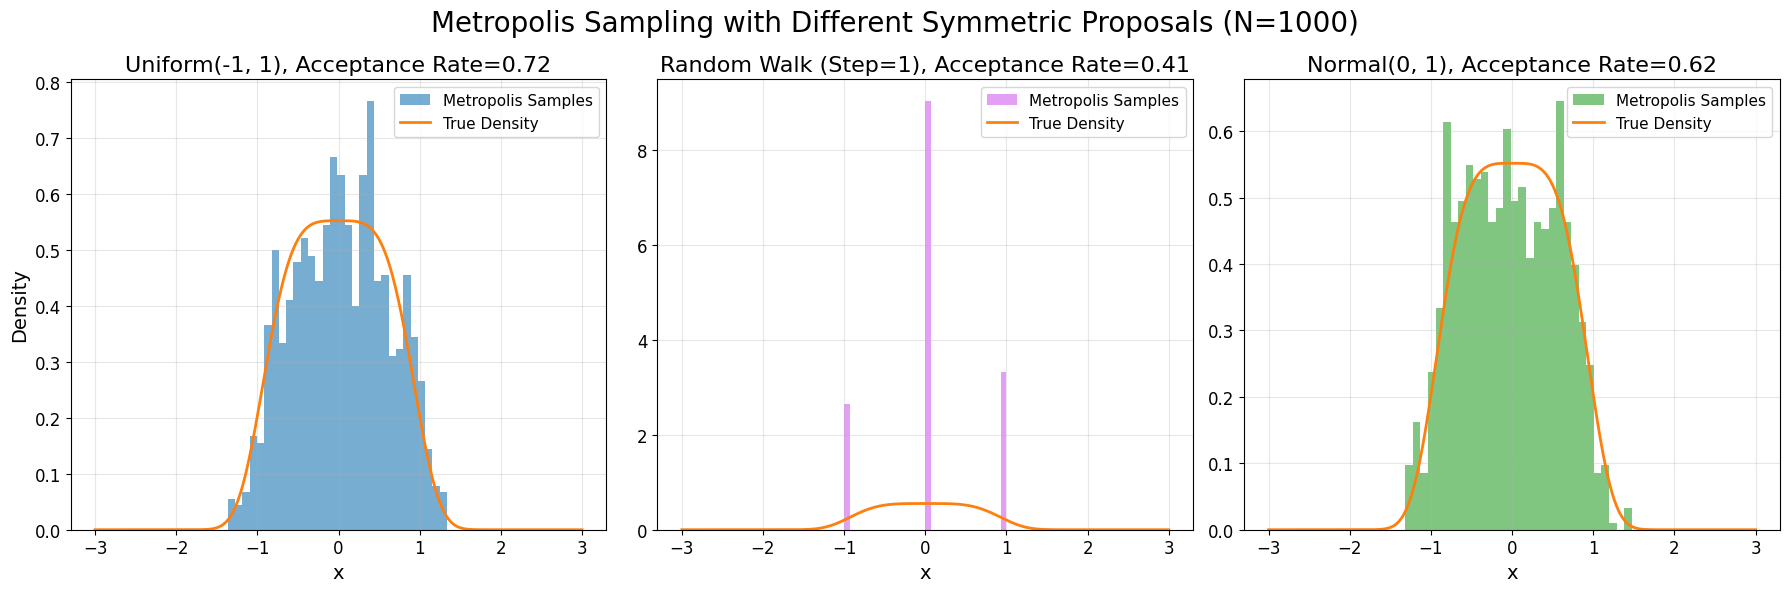

In [116]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# ---------- First plot ----------
ax[0].hist(samples_uniform,
           bins=B1,
           density=True,
           alpha=0.6,
           color=UNIFORM_COLOR,
           label="Metropolis Samples")

ax[0].plot(x_vals,
           true_density,
           linewidth=2,
           color=TRUE_DENSITY_COLOR,
           label="True Density")

ax[0].set_title(
    f"Uniform(-{UNIFORM_STEP}, {UNIFORM_STEP}), Acceptance Rate={acc_uniform:.2f}",
    fontsize=TITLE_SIZE
)

ax[0].set_xlabel("x", fontsize=LABEL_SIZE)
ax[0].set_ylabel("Density", fontsize=LABEL_SIZE)

ax[0].tick_params(axis='both', labelsize=TICK_SIZE)

ax[0].grid(True, alpha=0.3)

ax[0].legend(fontsize=LEGEND_SIZE)

# ---------- Second plot ----------
ax[1].hist(samples_rw,
           bins=B2,
           density=True,
           alpha=0.6,
           color=RANDOM_WALK_COLOR,
           label="Metropolis Samples")

ax[1].plot(x_vals,
           true_density,
           linewidth=2,
           color=TRUE_DENSITY_COLOR,
           label="True Density")

ax[1].set_title(
    f"Random Walk (Step={RW_STEP}), Acceptance Rate={acc_rw:.2f}",
    fontsize=TITLE_SIZE
)

ax[1].set_xlabel("x", fontsize=LABEL_SIZE)

ax[1].tick_params(axis='both', labelsize=TICK_SIZE)

ax[1].grid(True, alpha=0.3)

ax[1].legend(fontsize=LEGEND_SIZE)

# ---------- Third plot ----------
ax[2].hist(samples_normal,
           bins=B3,
           density=True,
           alpha=0.6,
           color=NORMAL_COLOR,
           label="Metropolis Samples")

ax[2].plot(x_vals,
           true_density,
           linewidth=2,
           color=TRUE_DENSITY_COLOR,
           label="True Density")

ax[2].set_title(
    f"Normal(0, {SIGMA}), Acceptance Rate={acc_normal:.2f}",
    fontsize=TITLE_SIZE
)

ax[2].set_xlabel("x", fontsize=LABEL_SIZE)

ax[2].tick_params(axis='both', labelsize=TICK_SIZE)

ax[2].grid(True, alpha=0.3)

ax[2].legend(fontsize=LEGEND_SIZE)

# Global title
plt.suptitle(
    f"Metropolis Sampling with Different Symmetric Proposals (N={N})",
    fontsize=20,
)

# Better spacing
plt.tight_layout()

# High quality export
plt.savefig(
    "figures\\q2_compare_proposals.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Trace plots

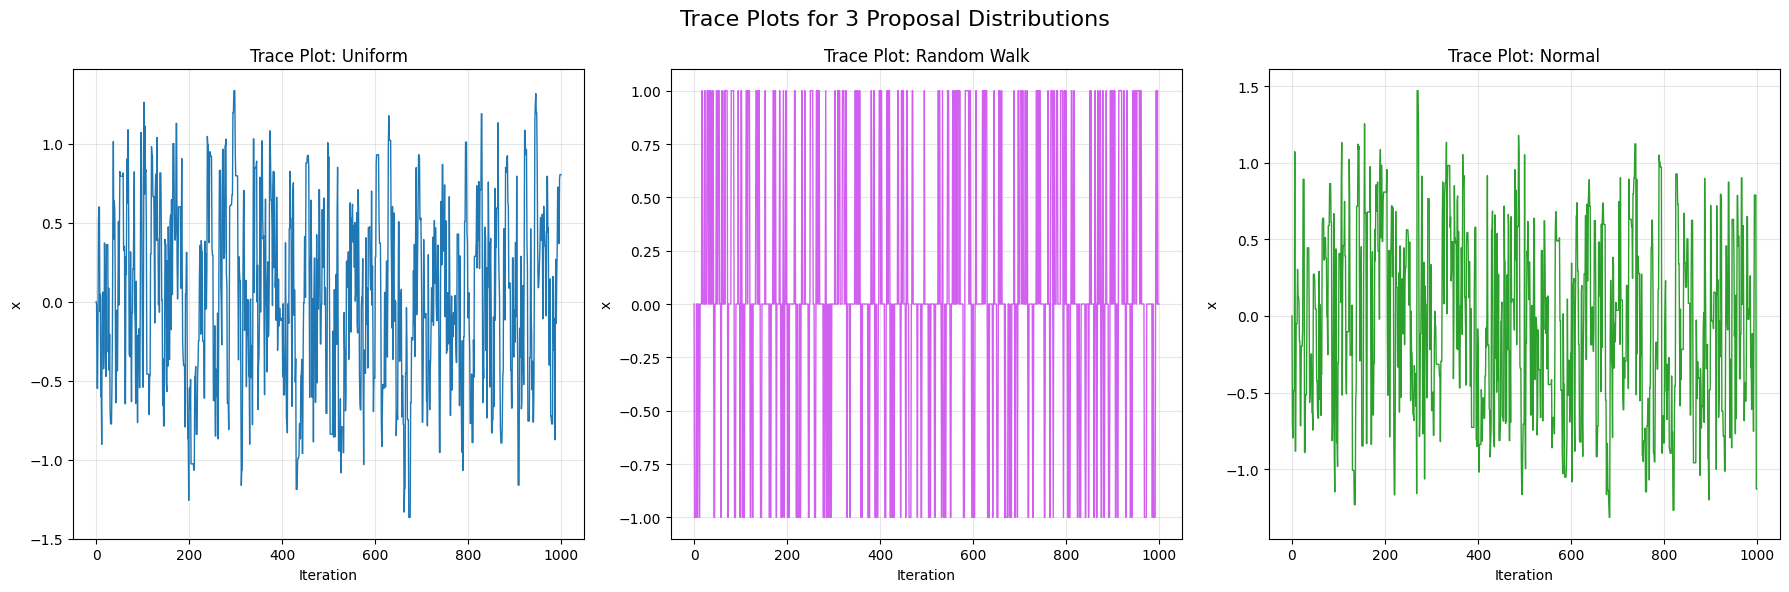

In [117]:
PROPOSAL_COLORS = {
    "Uniform": UNIFORM_COLOR,
    "Random Walk": RANDOM_WALK_COLOR,
    "Normal": NORMAL_COLOR,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for ax, (proposal_name, result) in zip(axes, metropolis_results.items()):

    samples = result["samples"]

    ax.plot(samples, linewidth=1, color=PROPOSAL_COLORS[proposal_name])

    ax.set_title(f"Trace Plot: {proposal_name}")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("x")
    ax.grid(True, alpha=0.3)

plt.suptitle("Trace Plots for 3 Proposal Distributions", fontsize=16)
plt.tight_layout()
plt.savefig(
    "figures\\q2_trace_plots.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Running mean convergence
Since f(x) is symmetric around 0, the true mean is 0. The running mean should move toward 0 if sampling works well.

Uniform sample mean: 0.0283
Random Walk sample mean: 0.0460
Normal sample mean: -0.0433


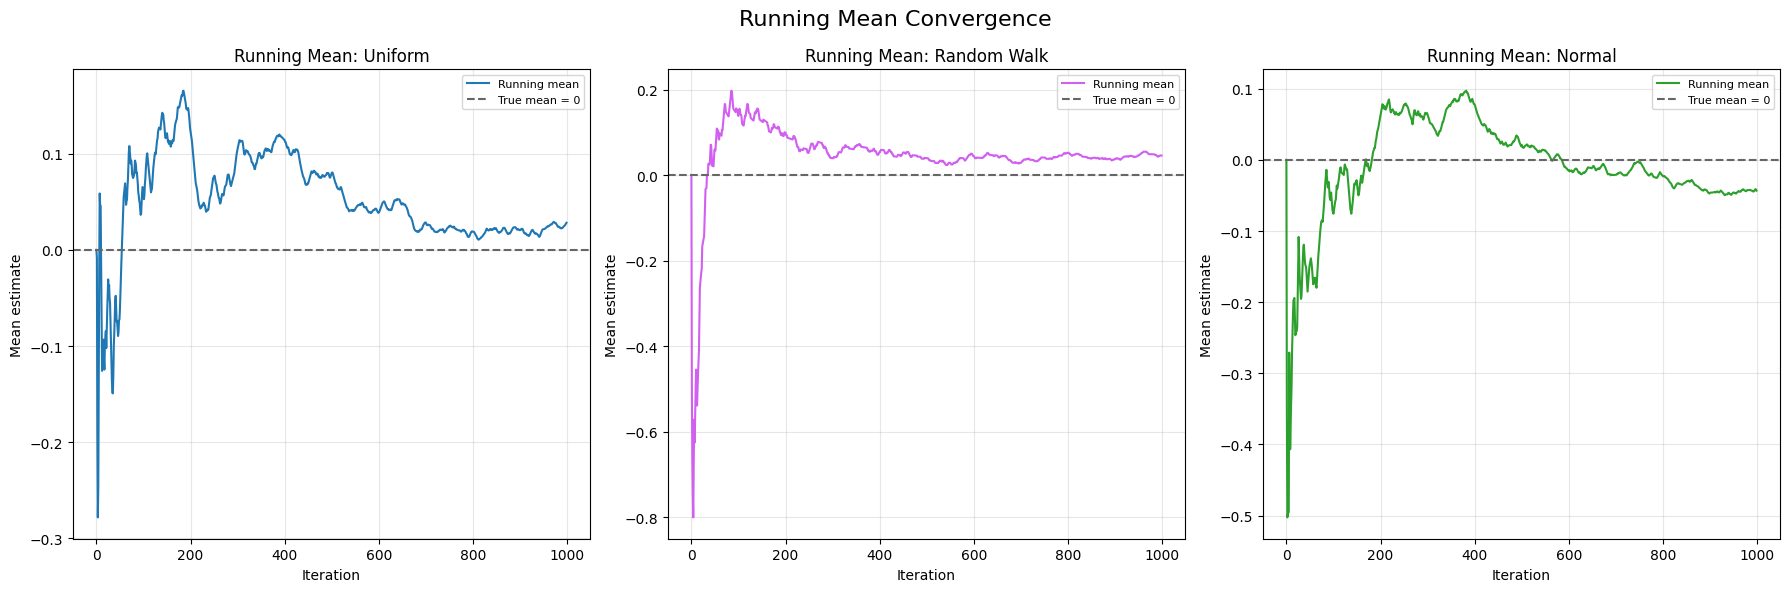

In [118]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (proposal_name, result) in zip(axes, metropolis_results.items()):

    samples = result["samples"]
    running_mean = np.cumsum(samples) / np.arange(1, len(samples) + 1)

    ax.plot(running_mean, linewidth=1.5, color=PROPOSAL_COLORS[proposal_name], label="Running mean")
    ax.axhline(0, linestyle="--", linewidth=1.5, color="#666666", label="True mean = 0")

    ax.set_title(f"Running Mean: {proposal_name}")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Mean estimate")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    sample_mean = np.mean(samples)
    print(f"{proposal_name} sample mean: {sample_mean:.4f}")
    
plt.suptitle("Running Mean Convergence", fontsize=16)
plt.tight_layout()
plt.savefig(
    "figures\\q2_running_mean_convergence.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Step 11: Autocorrelation function
Lower autocorrelation usually means better mixing. If autocorrelation stays high, samples are strongly dependent.

In [119]:
def autocorrelation(samples, max_lag=50):
    """
    Compute autocorrelation values up to max_lag.
    """

    samples = np.asarray(samples)
    samples_centered = samples - np.mean(samples)

    acf_values = []

    for lag in range(max_lag + 1):

        if lag == 0:
            acf_values.append(1.0)
        else:
            corr = np.corrcoef(
                samples_centered[:-lag],
                samples_centered[lag:]
            )[0, 1]
            acf_values.append(corr)

    return np.array(acf_values)

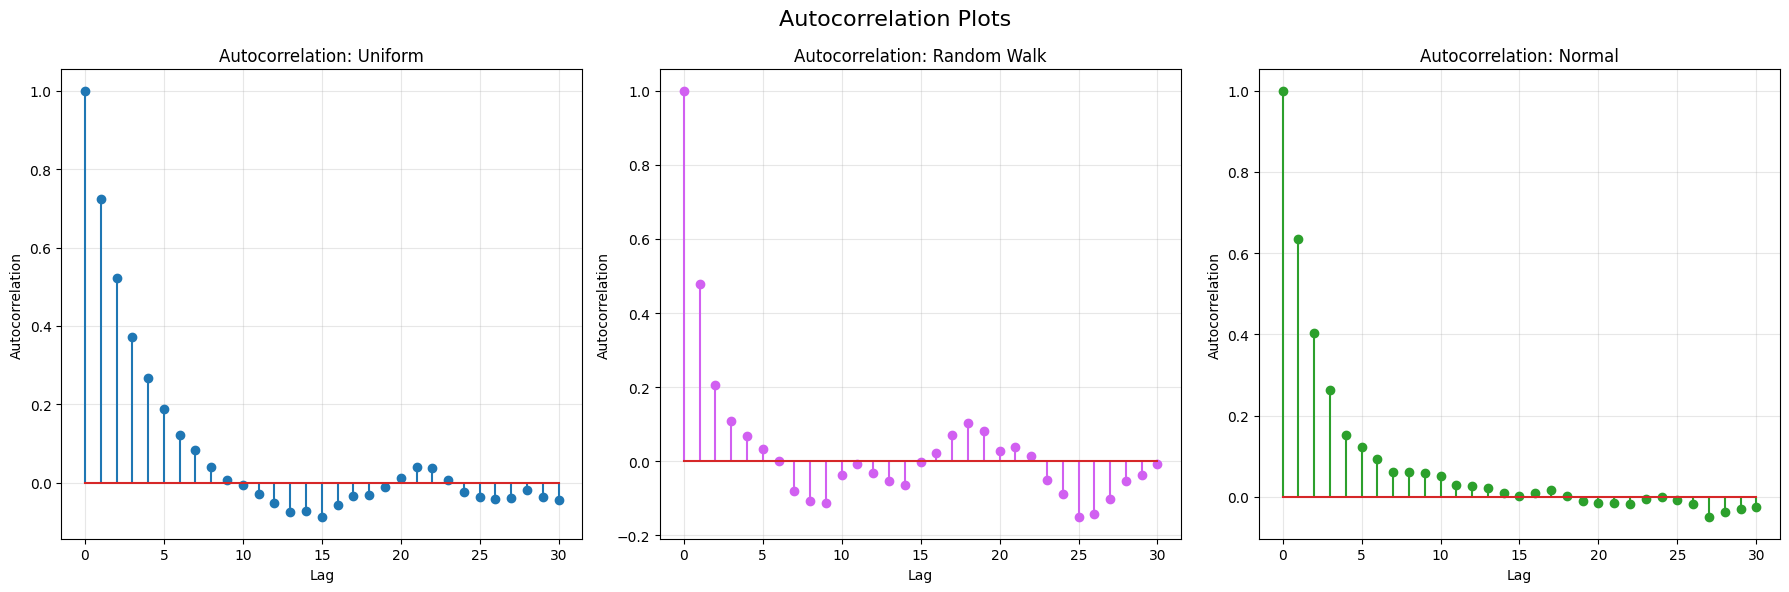

In [120]:
max_lag = 30


fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for ax, (proposal_name, result) in zip(axes, metropolis_results.items()):

    samples = result["samples"]
    acf_values = autocorrelation(samples, max_lag=max_lag)

    markerline, stemlines, baseline = ax.stem(
        range(max_lag + 1),
        acf_values
    )
    plt.setp(markerline, color=PROPOSAL_COLORS[proposal_name])
    plt.setp(stemlines, color=PROPOSAL_COLORS[proposal_name])

    ax.set_title(f"Autocorrelation: {proposal_name}")
    ax.set_xlabel("Lag")
    ax.set_ylabel("Autocorrelation")
    ax.grid(True, alpha=0.3)

plt.suptitle("Autocorrelation Plots", fontsize=16, )
plt.tight_layout()
plt.savefig(
    "figures\\q2_autocorrelation_comparison.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Numerical performance table

In [121]:
performance_rows = []

# Theoretical moment values
true_mean = 0.0
true_fourth_moment = 1 / 4

def distribution_l1_error(samples, bins=80, x_range=(-3, 3)):
    """
    Measures how close the sampled histogram is to the true density.
    Smaller value means better convergence.
    """

    hist_density, bin_edges = np.histogram(
        samples,
        bins=bins,
        range=x_range,
        density=True
    )

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    dx = bin_edges[1] - bin_edges[0]

    true_vals = target_fn(bin_centers, Z)

    l1_error = np.sum(np.abs(hist_density - true_vals)) * dx

    return l1_error

for proposal_name, result in metropolis_results.items():

    samples = result["samples"]
    acceptance_rate = result["acceptance_rate"]

    sample_mean = np.mean(samples)
    sample_variance = np.var(samples)
    sample_fourth_moment = np.mean(samples**4)

    mean_abs_error = abs(sample_mean - true_mean)
    fourth_moment_abs_error = abs(sample_fourth_moment - true_fourth_moment)

    distribution_error = distribution_l1_error(samples)

    performance_rows.append({
        "Proposal": proposal_name,
        "Acceptance Rate": acceptance_rate,
        "Sample Mean": sample_mean,
        "Mean Absolute Error": mean_abs_error,
        "Sample Variance": sample_variance,
        "Sample E[X^4]": sample_fourth_moment,
        "True E[X^4]": true_fourth_moment,
        "E[X^4] Absolute Error": fourth_moment_abs_error,
        "Distribution L1 Error": distribution_error
    })

performance_table = pd.DataFrame(performance_rows)

performance_table

,Proposal,Acceptance Rate,Sample Mean,Mean Absolute Error,Sample Variance,Sample E[X^4],True E[X^4],E[X^4] Absolute Error,Distribution L1 Error
0,Uniform,0.717718,0.028264,0.028264,0.344338,0.260960,0.25,0.010960,0.198721
1,Random Walk,0.414414,0.046000,0.046000,0.395884,0.398000,0.25,0.148000,1.859399
2,Normal,0.624625,-0.043253,0.043253,0.358339,0.263659,0.25,0.013659,0.155696


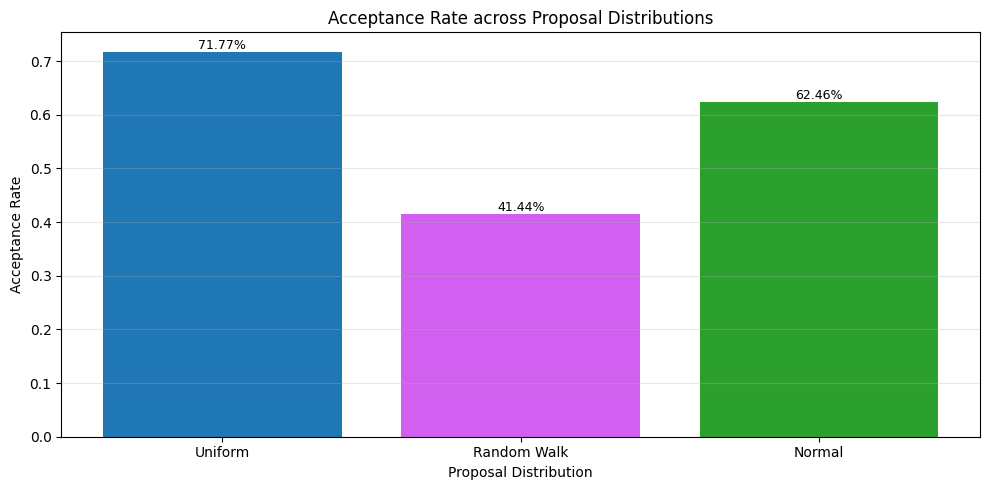

In [122]:
# Acceptance Rate Comparison

plt.figure(figsize=(10, 5))
plt.bar(performance_table["Proposal"],
      performance_table["Acceptance Rate"],
      color=[PROPOSAL_COLORS.get(p) for p in performance_table["Proposal"]]
)

plt.title("Acceptance Rate across Proposal Distributions")
plt.xlabel("Proposal Distribution")
plt.ylabel("Acceptance Rate")
plt.grid(axis="y", alpha=0.3)

for i, value in enumerate(performance_table["Acceptance Rate"]):
    plt.text(i, value, f"{value:.2%}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(
    "figures\\q2_acceptance_rate_comparison.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Extra Exploration

### Comparison of distribution as N increases

In [123]:
# ============================================================
# Further Exploration:
# Convergence comparison as N increases
# ============================================================

import contextlib
import io
import random

# Discrete N values: 10, 50, 100, 150, ..., 10000
N_values = np.concatenate(([10], np.arange(50, 10001, 50)))


# Histogram settings for measuring distribution error
ERROR_BINS = 80
ERROR_RANGE = (-3, 3)

def distribution_l1_error(samples, bins=ERROR_BINS, x_range=ERROR_RANGE):
    """
    Compare empirical sampled distribution with the true density.
    Smaller L1 error means the sampled distribution is closer to the true distribution.
    """

    hist_density, bin_edges = np.histogram(
        samples,
        bins=bins,
        range=x_range,
        density=True
    )

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    dx = bin_edges[1] - bin_edges[0]

    true_vals = target_fn(bin_centers, Z)

    l1_error = np.sum(np.abs(hist_density - true_vals)) * dx

    return l1_error


convergence_rows = []

for N_current in N_values:

    # Suppress acceptance-rate printing from universal_metropolis_sampler
    with contextlib.redirect_stdout(io.StringIO()):

        samples_uniform, acc_uniform = universal_metropolis_sampler(
            dist="uniform",
            num_samples=N_current,
            initial_x=INITIAL_X,
            z=Z,
            step_size=UNIFORM_STEP
        )

        samples_rw, acc_rw = universal_metropolis_sampler(
            dist="rw",
            num_samples=N_current,
            initial_x=INITIAL_X,
            z=Z,
            step_size=RW_STEP
        )

        samples_normal, acc_normal = universal_metropolis_sampler(
            dist="normal",
            num_samples=N_current,
            initial_x=INITIAL_X,
            z=Z,
            sigma=SIGMA
        )

    convergence_rows.append({
        "N": N_current,
        "Proposal": "Uniform",
        "Distribution Error": distribution_l1_error(samples_uniform),
        "Acceptance Rate": acc_uniform
    })

    convergence_rows.append({
        "N": N_current,
        "Proposal": "Random Walk",
        "Distribution Error": distribution_l1_error(samples_rw),
        "Acceptance Rate": acc_rw
    })

    convergence_rows.append({
        "N": N_current,
        "Proposal": "Normal",
        "Distribution Error": distribution_l1_error(samples_normal),
        "Acceptance Rate": acc_normal
    })


convergence_df = pd.DataFrame(convergence_rows)

convergence_df.head()

,N,Proposal,Distribution Error,Acceptance Rate
0,10,Uniform,1.302387,1.000000
1,10,Random Walk,1.888327,0.222222
2,10,Normal,1.495968,0.666667
3,50,Uniform,0.779583,0.755102
4,50,Random Walk,1.859399,0.367347


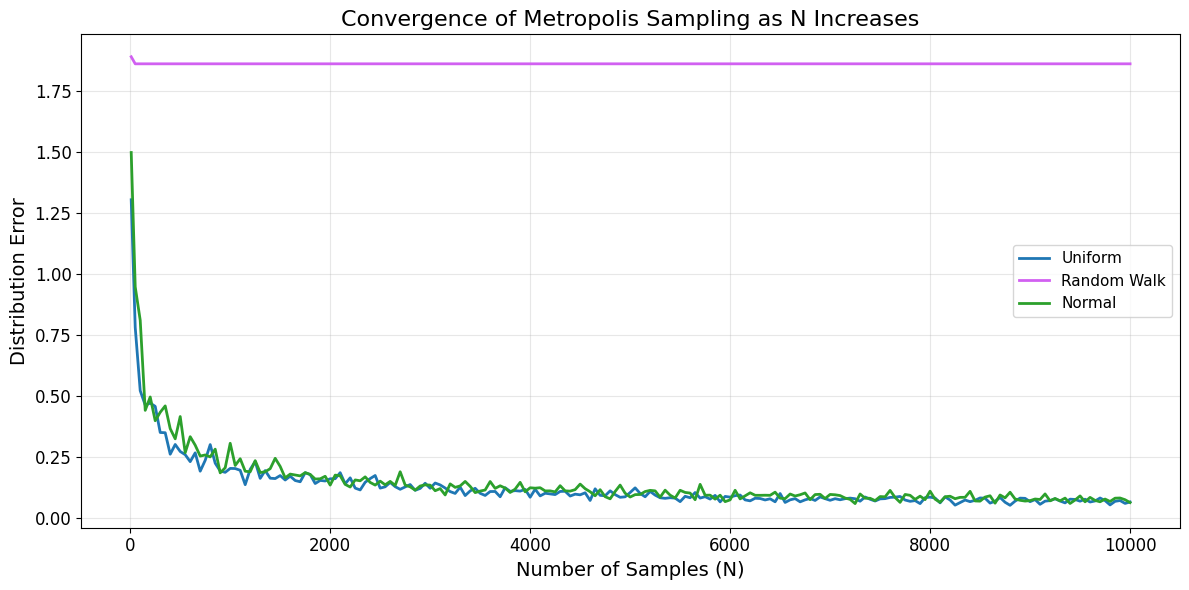

In [124]:
# ============================================================
# Plot convergence comparison
# ============================================================

PROPOSAL_COLORS = {
    "Uniform": UNIFORM_COLOR,
    "Random Walk": RANDOM_WALK_COLOR,
    "Normal": NORMAL_COLOR,
}

fig, ax = plt.subplots(figsize=(12, 6))

for proposal_name in ["Uniform", "Random Walk", "Normal"]:

    proposal_df = convergence_df[
        convergence_df["Proposal"] == proposal_name
    ]

    ax.plot(
        proposal_df["N"],
        proposal_df["Distribution Error"],
        linewidth=2,
        color=PROPOSAL_COLORS[proposal_name],
        label=proposal_name
    )

ax.set_title(
    "Convergence of Metropolis Sampling as N Increases",
    fontsize=TITLE_SIZE
)

ax.set_xlabel("Number of Samples (N)", fontsize=LABEL_SIZE)
ax.set_ylabel("Distribution Error", fontsize=LABEL_SIZE)

ax.tick_params(axis="both", labelsize=TICK_SIZE)

ax.grid(True, alpha=0.3)
ax.legend(fontsize=LEGEND_SIZE)

plt.tight_layout()

plt.savefig(
    "figures\\q2_convergence_comparison.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [125]:
# ============================================================
# Reproducible Step Size Comparison
# ============================================================

import contextlib
import io
import random

N = 10000
INITIAL_X = 0.0
BASE_SEED = 0

STEP_VALUES = [
    0.01, 0.025, 0.05, 0.075,
    0.1, 0.2, 0.3, 0.5,
    0.75, 1.0, 1.25, 1.5, 1.75, 2.0
]

def reset_rngs(seed):
    """
    Reset every RNG used by the notebook.
    np.random.seed() only resets legacy np.random calls, not default_rng objects.
    """
    global rng_proposal, rng_metropolis

    random.seed(seed + 2)
    np.random.seed(seed + 3)

    rng_proposal.bit_generator.state = np.random.default_rng(seed).bit_generator.state
    rng_metropolis.bit_generator.state = np.random.default_rng(seed + 1).bit_generator.state


proposal_step_results = []

for i, step in enumerate(STEP_VALUES):

    # ---------- Uniform ----------
    reset_rngs(BASE_SEED + i * 100)

    with contextlib.redirect_stdout(io.StringIO()):
        samples_uniform, acc_uniform = universal_metropolis_sampler(
            dist="uniform",
            num_samples=N,
            initial_x=INITIAL_X,
            z=Z,
            step_size=step
        )

    proposal_step_results.append({
        "Proposal": "Uniform",
        "Step Parameter": step,
        "Acceptance Rate": acc_uniform,
        "Mean Estimate": np.mean(samples_uniform),
        "Mean Error": abs(np.mean(samples_uniform)),
        "E[X^4] Estimate": np.mean(samples_uniform**4),
        "E[X^4] Error": abs(np.mean(samples_uniform**4) - 0.25),
        "Distribution Error": distribution_l1_error(samples_uniform)
    })


    # ---------- Random Walk ----------
    reset_rngs(BASE_SEED + i * 100 + 10)

    with contextlib.redirect_stdout(io.StringIO()):
        samples_rw, acc_rw = universal_metropolis_sampler(
            dist="rw",
            num_samples=N,
            initial_x=INITIAL_X,
            z=Z,
            step_size=step
        )

    proposal_step_results.append({
        "Proposal": "Random Walk",
        "Step Parameter": step,
        "Acceptance Rate": acc_rw,
        "Mean Estimate": np.mean(samples_rw),
        "Mean Error": abs(np.mean(samples_rw)),
        "E[X^4] Estimate": np.mean(samples_rw**4),
        "E[X^4] Error": abs(np.mean(samples_rw**4) - 0.25),
        "Distribution Error": distribution_l1_error(samples_rw)
    })


    # ---------- Normal ----------
    reset_rngs(BASE_SEED + i * 100 + 20)

    with contextlib.redirect_stdout(io.StringIO()):
        samples_normal, acc_normal = universal_metropolis_sampler(
            dist="normal",
            num_samples=N,
            initial_x=INITIAL_X,
            z=Z,
            sigma=step
        )

    proposal_step_results.append({
        "Proposal": "Normal",
        "Step Parameter": step,
        "Acceptance Rate": acc_normal,
        "Mean Estimate": np.mean(samples_normal),
        "Mean Error": abs(np.mean(samples_normal)),
        "E[X^4] Estimate": np.mean(samples_normal**4),
        "E[X^4] Error": abs(np.mean(samples_normal**4) - 0.25),
        "Distribution Error": distribution_l1_error(samples_normal)
    })


proposal_step_df = pd.DataFrame(proposal_step_results)

proposal_step_df

,Proposal,Step Parameter,Acceptance Rate,Mean Estimate,Mean Error,E[X^4] Estimate,E[X^4] Error,Distribution Error
0,Uniform,0.010,0.999800,-0.132687,0.132687,0.006677,0.243323,1.133715
1,Random Walk,0.010,0.998400,-0.239602,0.239602,0.075451,0.174549,0.619277
2,Normal,0.010,0.991199,-0.589308,0.589308,0.717686,0.467686,0.972570
3,Uniform,0.025,0.997700,-0.002363,0.002363,0.091716,0.158284,0.441615
4,Random Walk,0.025,0.985699,0.157153,0.157153,0.271828,0.021828,0.335415
5,Normal,0.025,0.994199,-0.238996,0.238996,0.090176,0.159824,0.562980
6,Uniform,0.050,0.986799,-0.095056,0.095056,0.209901,0.040099,0.286210
7,Random Walk,0.050,0.963496,0.189100,0.189100,0.315379,0.065379,0.391427
8,Normal,0.050,0.969997,0.106630,0.106630,0.361420,0.111420,0.267257
9,Uniform,0.075,0.982098,-0.042234,0.042234,0.205199,0.044801,0.186972


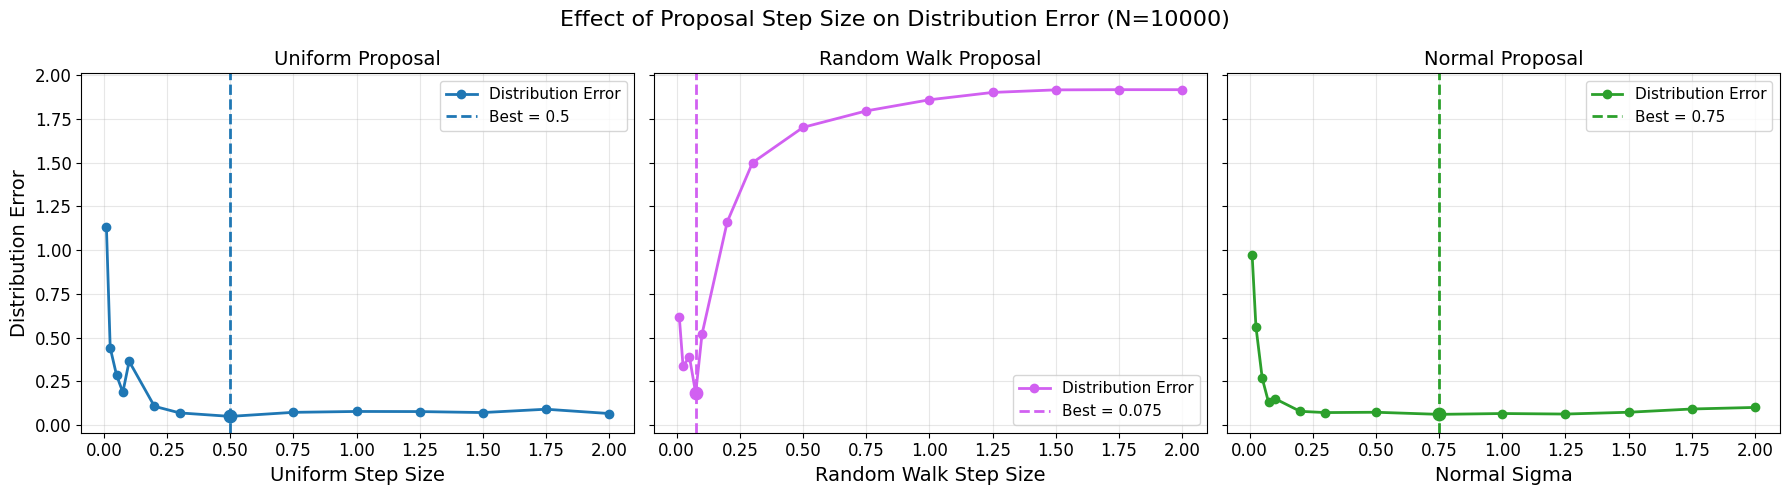

Best Uniform Step: 0.5
Best Random Walk Step: 0.075
Best Normal Sigma: 0.75


In [126]:
# ============================================================
# Plot Distribution Error vs Step Size
# ============================================================

proposal_configs = [
    ("Uniform", UNIFORM_COLOR, "Uniform Step Size"),
    ("Random Walk", RANDOM_WALK_COLOR, "Random Walk Step Size"),
    ("Normal", NORMAL_COLOR, "Normal Sigma"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

best_rows = {}

for ax, (proposal_name, color, xlabel) in zip(axes, proposal_configs):

    proposal_df = proposal_step_df[
        proposal_step_df["Proposal"] == proposal_name
    ].sort_values("Step Parameter")

    best_row = proposal_df.loc[proposal_df["Distribution Error"].idxmin()]
    best_rows[proposal_name] = best_row

    best_step = best_row["Step Parameter"]
    best_error = best_row["Distribution Error"]

    ax.plot(
        proposal_df["Step Parameter"],
        proposal_df["Distribution Error"],
        marker="o",
        linewidth=2,
        color=color,
        label="Distribution Error"
    )

    ax.axvline(
        best_step,
        linestyle="--",
        linewidth=2,
        color=color,
        label=f"Best = {best_step}"
    )

    ax.scatter(
        best_step,
        best_error,
        s=80,
        color=color,
        zorder=3
    )

    ax.set_title(f"{proposal_name} Proposal", fontsize=LABEL_SIZE)
    ax.set_xlabel(xlabel, fontsize=LABEL_SIZE)
    ax.tick_params(axis="both", labelsize=TICK_SIZE)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=LEGEND_SIZE)

axes[0].set_ylabel("Distribution Error", fontsize=LABEL_SIZE)

fig.suptitle(
    f"Effect of Proposal Step Size on Distribution Error (N={N})",
    fontsize=TITLE_SIZE
)

plt.tight_layout()

plt.savefig(
    "figures\\q2_step_size_distribution_error.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Best Uniform Step:", best_rows["Uniform"]["Step Parameter"])
print("Best Random Walk Step:", best_rows["Random Walk"]["Step Parameter"])
print("Best Normal Sigma:", best_rows["Normal"]["Step Parameter"])

In [127]:
# ============================================================
# Further Exploration:
# Plot the distribution of samples for the best step size
# ============================================================

# Best random walk step size from previous analysis
UNIFORM_STEP = best_rows["Uniform"]["Step Parameter"]
RW_STEP = best_rows["Random Walk"]["Step Parameter"]
SIGMA = best_rows["Normal"]["Step Parameter"]


convergence_rows = []

for N_current in N_values:

    # Suppress acceptance-rate printing from universal_metropolis_sampler
    with contextlib.redirect_stdout(io.StringIO()):

        samples_uniform, acc_uniform = universal_metropolis_sampler(
            dist="uniform",
            num_samples=N_current,
            initial_x=INITIAL_X,
            z=Z,
            step_size=UNIFORM_STEP
        )

        samples_rw, acc_rw = universal_metropolis_sampler(
            dist="rw",
            num_samples=N_current,
            initial_x=INITIAL_X,
            z=Z,
            step_size=RW_STEP
        )

        samples_normal, acc_normal = universal_metropolis_sampler(
            dist="normal",
            num_samples=N_current,
            initial_x=INITIAL_X,
            z=Z,
            sigma=SIGMA
        )

    convergence_rows.append({
        "N": N_current,
        "Proposal": "Uniform",
        "Distribution Error": distribution_l1_error(samples_uniform),
        "Acceptance Rate": acc_uniform
    })

    convergence_rows.append({
        "N": N_current,
        "Proposal": "Random Walk",
        "Distribution Error": distribution_l1_error(samples_rw),
        "Acceptance Rate": acc_rw
    })

    convergence_rows.append({
        "N": N_current,
        "Proposal": "Normal",
        "Distribution Error": distribution_l1_error(samples_normal),
        "Acceptance Rate": acc_normal
    })


convergence_df = pd.DataFrame(convergence_rows)

convergence_df.head()

,N,Proposal,Distribution Error,Acceptance Rate
0,10,Uniform,1.460050,0.888889
1,10,Random Walk,1.669137,1.000000
2,10,Normal,1.377725,0.888889
3,50,Uniform,0.645747,0.857143
4,50,Random Walk,1.292693,0.979592


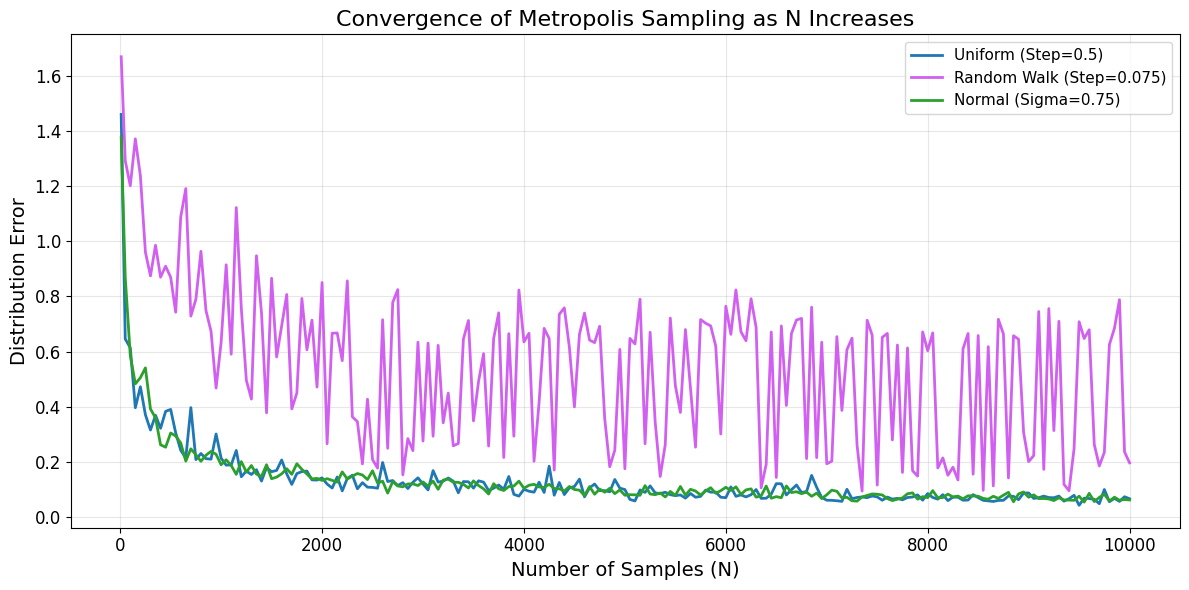

In [128]:
# ============================================================
# Plot convergence comparison
# ============================================================

PROPOSAL_COLORS = {
    "Uniform": UNIFORM_COLOR,
    "Random Walk": RANDOM_WALK_COLOR,
    "Normal": NORMAL_COLOR,
}

fig, ax = plt.subplots(figsize=(12, 6))

for proposal_name in ["Uniform", "Random Walk", "Normal"]:

    proposal_df = convergence_df[
        convergence_df["Proposal"] == proposal_name
    ]

    label_name = proposal_name
    if proposal_name == "Random Walk":
        label_name += f" (Step={RW_STEP})"
    elif proposal_name == "Uniform":
        label_name += f" (Step={UNIFORM_STEP})"
    elif proposal_name == "Normal":
        label_name += f" (Sigma={SIGMA})"


    ax.plot(
        proposal_df["N"],
        proposal_df["Distribution Error"],
        linewidth=2,
        color=PROPOSAL_COLORS[proposal_name],
        label=label_name 
    )

ax.set_title(
    "Convergence of Metropolis Sampling as N Increases",
    fontsize=TITLE_SIZE
)

ax.set_xlabel("Number of Samples (N)", fontsize=LABEL_SIZE)
ax.set_ylabel("Distribution Error", fontsize=LABEL_SIZE)

ax.tick_params(axis="both", labelsize=TICK_SIZE)

ax.grid(True, alpha=0.3)
ax.legend(fontsize=LEGEND_SIZE)

plt.tight_layout()

plt.savefig(
    "figures\\q2_convergence_comparison.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

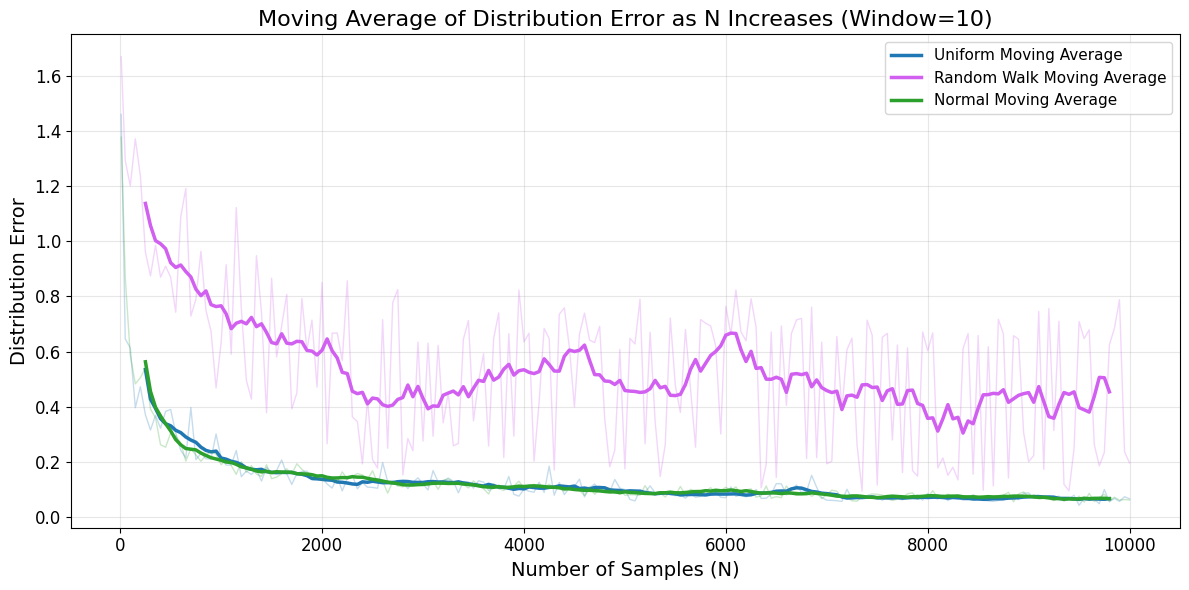

In [129]:
# ============================================================
# Moving Average Plot for Distribution Error
# ============================================================

MOVING_AVG_WINDOW = 10   # try 10 or 20

fig, ax = plt.subplots(figsize=(12, 6))

proposal_styles = {
    "Uniform": {
        "color": UNIFORM_COLOR,
        "label": "Uniform"
    },
    "Random Walk": {
        "color": RANDOM_WALK_COLOR,
        "label": "Random Walk"
    },
    "Normal": {
        "color": NORMAL_COLOR,
        "label": "Normal"
    }
}

for proposal_name, style in proposal_styles.items():

    proposal_df = convergence_df[
        convergence_df["Proposal"] == proposal_name
    ].sort_values("N").copy()

    proposal_df["Moving Average"] = (
        proposal_df["Distribution Error"]
        .rolling(window=MOVING_AVG_WINDOW, center=True)
        .mean()
    )

    # Raw line, lighter
    ax.plot(
        proposal_df["N"],
        proposal_df["Distribution Error"],
        linewidth=1,
        alpha=0.25,
        color=style["color"]
    )

    # Moving average line
    ax.plot(
        proposal_df["N"],
        proposal_df["Moving Average"],
        linewidth=2.5,
        color=style["color"],
        label=f"{style['label']} Moving Average"
    )

ax.set_title(
    f"Moving Average of Distribution Error as N Increases "
    f"(Window={MOVING_AVG_WINDOW})",
    fontsize=TITLE_SIZE
)

ax.set_xlabel("Number of Samples (N)", fontsize=LABEL_SIZE)
ax.set_ylabel("Distribution Error", fontsize=LABEL_SIZE)

ax.tick_params(axis="both", labelsize=TICK_SIZE)

ax.grid(True, alpha=0.3)
ax.legend(fontsize=LEGEND_SIZE)

plt.tight_layout()

plt.savefig(
    "figures\\q2_convergence_moving_average.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Plot 3 Distribution Using Larger N and optimal step size

Acceptance rate: 0.8631
Acceptance rate: 0.9594
Acceptance rate: 0.6783
Distribution error for Uniform: 0.02097672090491938
Distribution error for Random Walk: 0.6511324176532446
Distribution error for Normal: 0.024481304313258276


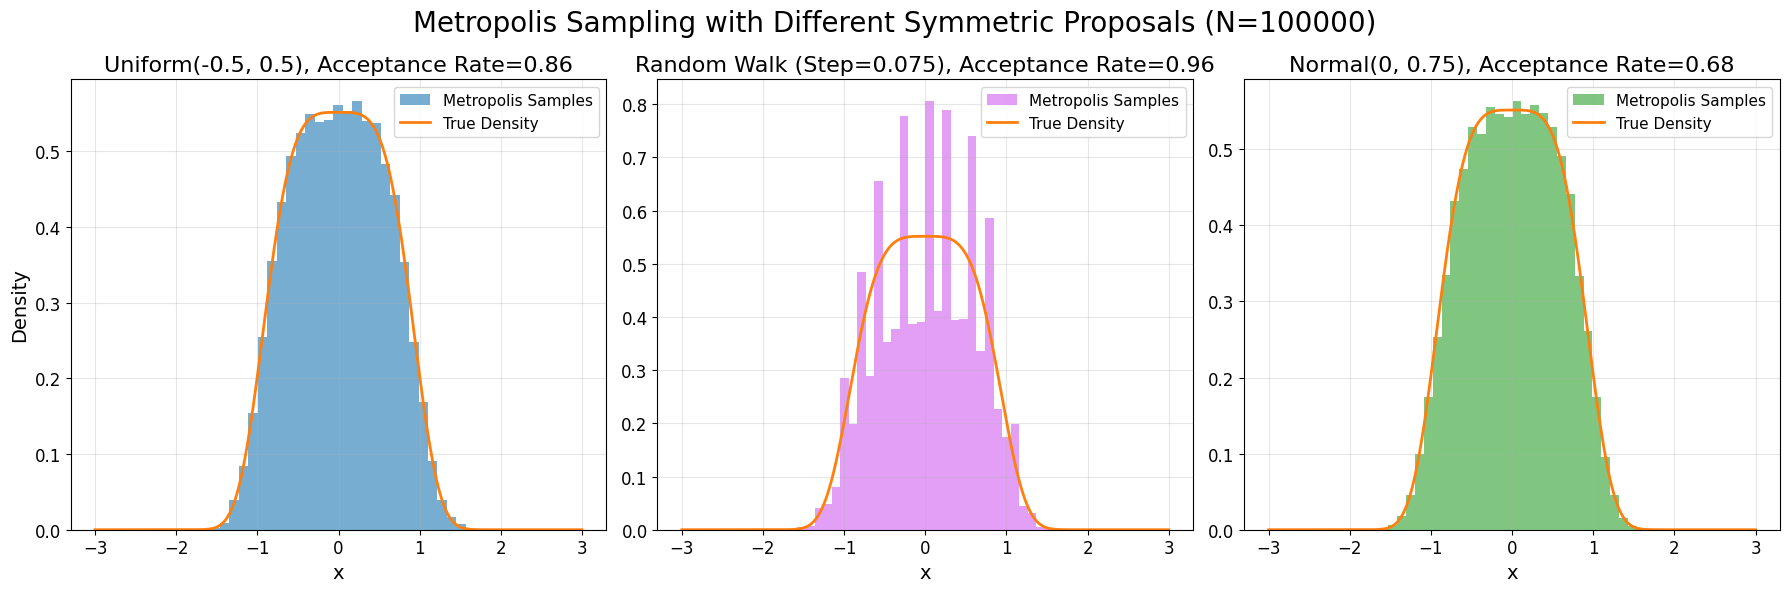

In [ ]:
N = 10000

metropolis_results = {}
# True density based on samples
x_vals = np.linspace(-3, 3, 500)
true_density = target_fn(x_vals, Z)

# Metropolis samples
samples_uniform, acc_uniform = universal_metropolis_sampler(dist="uniform", num_samples=N, z=Z,
                                                            initial_x=INITIAL_X, step_size=UNIFORM_STEP)
samples_rw, acc_rw = universal_metropolis_sampler(dist="rw", num_samples=N, z=Z,
                                                  initial_x=INITIAL_X, step_size=RW_STEP)
samples_normal, acc_normal = universal_metropolis_sampler(dist="normal", num_samples=N, z=Z,
                                                          initial_x=INITIAL_X, sigma=SIGMA)

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# ---------- First plot ----------
ax[0].hist(samples_uniform,
           bins=B1,
           density=True,
           alpha=0.6,
           color=UNIFORM_COLOR,
           label="Metropolis Samples")

ax[0].plot(x_vals,
           true_density,
           linewidth=2,
           color=TRUE_DENSITY_COLOR,
           label="True Density")

ax[0].set_title(
    f"Uniform(-{UNIFORM_STEP}, {UNIFORM_STEP}), Acceptance Rate={acc_uniform:.2f}",
    fontsize=TITLE_SIZE
)

ax[0].set_xlabel("x", fontsize=LABEL_SIZE)
ax[0].set_ylabel("Density", fontsize=LABEL_SIZE)

ax[0].tick_params(axis='both', labelsize=TICK_SIZE)

ax[0].grid(True, alpha=0.3)

ax[0].legend(fontsize=LEGEND_SIZE)

# ---------- Second plot ----------
ax[1].hist(samples_rw,
           bins=B2,
           density=True,
           alpha=0.6,
           color=RANDOM_WALK_COLOR,
           label="Metropolis Samples")

ax[1].plot(x_vals,
           true_density,
           linewidth=2,
           color=TRUE_DENSITY_COLOR,
           label="True Density")

ax[1].set_title(
    f"Random Walk (Step={RW_STEP}), Acceptance Rate={acc_rw:.2f}",
    fontsize=TITLE_SIZE
)

ax[1].set_xlabel("x", fontsize=LABEL_SIZE)

ax[1].tick_params(axis='both', labelsize=TICK_SIZE)

ax[1].grid(True, alpha=0.3)

ax[1].legend(fontsize=LEGEND_SIZE)

# ---------- Third plot ----------
ax[2].hist(samples_normal,
           bins=B3,
           density=True,
           alpha=0.6,
           color=NORMAL_COLOR,
           label="Metropolis Samples")

ax[2].plot(x_vals,
           true_density,
           linewidth=2,
           color=TRUE_DENSITY_COLOR,
           label="True Density")

ax[2].set_title(
    f"Normal(0, {SIGMA}), Acceptance Rate={acc_normal:.2f}",
    fontsize=TITLE_SIZE
)

ax[2].set_xlabel("x", fontsize=LABEL_SIZE)

ax[2].tick_params(axis='both', labelsize=TICK_SIZE)

ax[2].grid(True, alpha=0.3)

ax[2].legend(fontsize=LEGEND_SIZE)

# Global title
plt.suptitle(
    f"Metropolis Sampling with Different Symmetric Proposals (N={N})",
    fontsize=20,
)

# Better spacing
plt.tight_layout()

# High quality export
plt.savefig(
    "figures\\q2_compare_proposals.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)

print("Distribution error for Uniform:", distribution_l1_error(samples_uniform))
print("Distribution error for Random Walk:", distribution_l1_error(samples_rw))
print("Distribution error for Normal:", distribution_l1_error(samples_normal))

plt.show()